In [34]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

In [35]:
train_dir = r"E:\Pyhton code\Data Sets\archive\skin_diseases\SkinDisease\SkinDisease\train"
test_dir = r"E:\Pyhton code\Data Sets\archive\skin_diseases\SkinDisease\SkinDisease\test"

In [36]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.3,
    horizontal_flip=True
)

test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=16,
    class_mode='categorical'
)

test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=16,
    class_mode='categorical'
)

Found 5592 images belonging to 8 classes.
Found 618 images belonging to 8 classes.


In [37]:
#check data
print(train_data.class_indices)
print(train_data.num_classes)

{'Acne': 0, 'Benign_tumors': 1, 'DrugEruption': 2, 'Eczema': 3, 'Infestations_Bites': 4, 'Psoriasis': 5, 'SkinCancer': 6, 'Sun_Sunlight_Damage': 7}
8


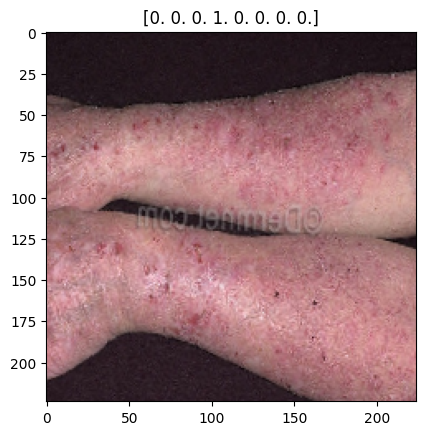

In [38]:
images, labels = next(train_data)
plt.imshow(images[0])
plt.title(labels[0])
plt.show()

In [39]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = True

for layer in base_model.layers[:-40]:
    layer.trainable = False   # freeze base

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.6),
    layers.Dense(train_data.num_classes, activation='softmax')
])

In [40]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [41]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [42]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 231s 613ms/step - accuracy: 0.2883 - loss: 2.4560 - val_accuracy: 0.3366 - val_loss: 2.0589
Epoch 2/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 312s 755ms/step - accuracy: 0.4149 - loss: 1.8438 - val_accuracy: 0.3010 - val_loss: 2.6186
Epoch 3/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 214s 610ms/step - accuracy: 0.4748 - loss: 1.6099 - val_accuracy: 0.3883 - val_loss: 1.7922
Epoch 4/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 207s 592ms/step - accuracy: 0.5075 - loss: 1.4598 - val_accuracy: 0.4191 - val_loss: 1.7656
Epoch 5/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 217s 618ms/step - accuracy: 0.5241 - loss: 1.3721 - val_accuracy: 0.3608 - val_loss: 2.1962
Epoch 6/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 227s 649ms/step - accuracy: 0.5477 - loss: 1.2936 - val_accuracy: 0.4094 - val_loss: 2.0558


In [48]:
loss, acc = model.evaluate(test_data)
print("Test Accuracy:", acc)

39/39 ━━━━━━━━━━━━━━━━━━━━ 7s 184ms/step - accuracy: 0.4191 - loss: 1.7656
Test Accuracy: 0.4190938472747803


In [49]:
model.save("skin_model.h5")

In [50]:
from tensorflow.keras.preprocessing import image

img_path = r"E:\Pyhton code\Data Sets\archive\skin_diseases\SkinDisease\SkinDisease\test\Acne\157__ProtectWyJQcm90ZWN0Il0_FocusFillWzI5NCwyMjIsIngiLDFd.jpeg"   # change this

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

pred = model.predict(img_array)

class_names = list(train_data.class_indices.keys())

print("Prediction:", class_names[np.argmax(pred)])
print("Confidence:", float(np.max(pred)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
Prediction: Acne
Confidence: 0.6265838146209717


In [51]:
import pickle

class_names = list(train_data.class_indices.keys())

pickle.dump(class_names, open("class_names.pkl", "wb"))

In [52]:
# from google.colab import files

# files.download("skin_model.h5")
# files.download("class_names.pkl")